## Title here
### Antara Mazumdar, Kai-Xing Yue


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import matplotlib.pyplot as plt
import numpy as np
import random

In [6]:
robbins_data=pd.read_csv('/content/drive/MyDrive/AstroStats Paper/lunar_crater_database_robbins_2018.csv')
# Check for missing values for Robbins
missing_values = robbins_data.isnull().sum()

for column in missing_values[missing_values > 0].index:
    missing_indices = robbins_data[robbins_data[column].isnull()].index
print(f"Indexes with missing values in columns: {list(missing_indices)}")
print(len(missing_indices))

# Drop missing values
robbins_data = robbins_data.drop(missing_indices)
print(len(robbins_data))

Indexes with missing values in columns: [9487, 138100, 139374, 156954, 243143, 247775, 275603, 330339, 333927, 336158, 341478, 348769, 373148, 380703, 385242, 395970, 488982, 522711, 525999, 534709, 542930, 545039, 647653, 680639, 680723, 693928, 700709, 701058, 705095, 705819, 825312, 832235, 835582, 855017, 1083694, 1223125, 1263215, 1280490]
38
1296758


In [ ]:
# Other sanity checks
for index, row in robbins_data.iterrows():
    if row['LON_CIRC_IMG'] > 360 or row['LON_CIRC_IMG'] < 0 :
        print(row['LON_CIRC_IMG'], 'is out of bounds')
    if row['LAT_CIRC_IMG'] > 90 or row['LAT_CIRC_IMG'] < -90 :
        print(row['LAT_CIRC_IMG'], 'is out of bounds')
    if row['DIAM_CIRC_SD_IMG'] < 0 :
        print(row['DIAM_CIRC_SD_IMG'], 'is out of bounds')

In [8]:
# Load neo data
neo_data = pd.read_csv('/content/drive/MyDrive/AstroStats Paper/output_million.txt', sep='\\s+')
missing_values2 = neo_data.isnull().sum()

missing_indices2 = []
for column in missing_values2[missing_values2 > 0].index:
    missing_indices2 = neo_data[neo_data[column].isnull()].index
print(f"Indexes with missing values in columns: {list(missing_indices2)}")
print(len(missing_indices2))
print(len(neo_data))

Indexes with missing values in columns: []
0
999999


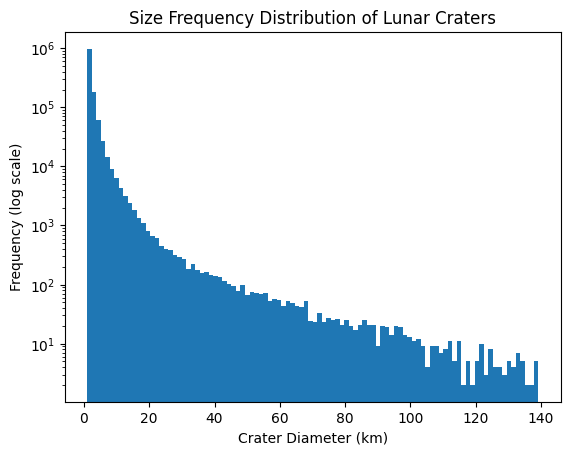

1296758
1296620


In [ ]:
# Plot crater SFD

plt.hist(robbins_data['DIAM_CIRC_IMG'][robbins_data['DIAM_CIRC_IMG']<=140], bins=100)
plt.xlabel('Crater Diameter (km)')
plt.ylabel('Frequency (log scale)')
plt.title('Size Frequency Distribution of Lunar Craters')
plt.yscale('log')
plt.show()
print(len(robbins_data))
print(len(robbins_data[robbins_data['DIAM_CIRC_IMG']<=140]))

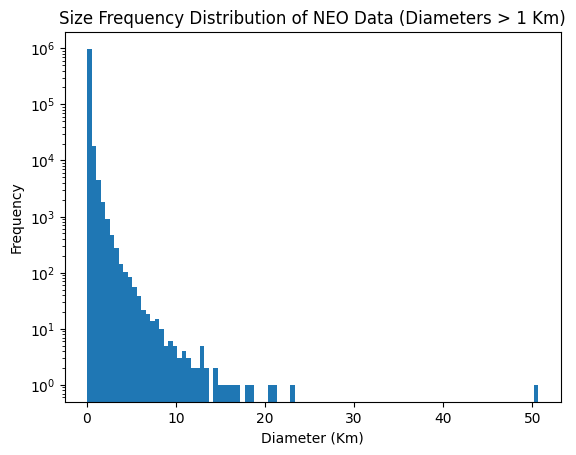

999999


In [10]:
plt.hist(neo_data.iloc[:, 4], bins=100)
plt.xlabel('Diameter (Km)')
plt.ylabel('Frequency')
plt.title('Size Frequency Distribution of NEO Data (Diameters > 1 Km)')
plt.yscale('log')
plt.show()
print(len(neo_data))

0.2000629178594573 0.1797365328057423 0.2335967506022032


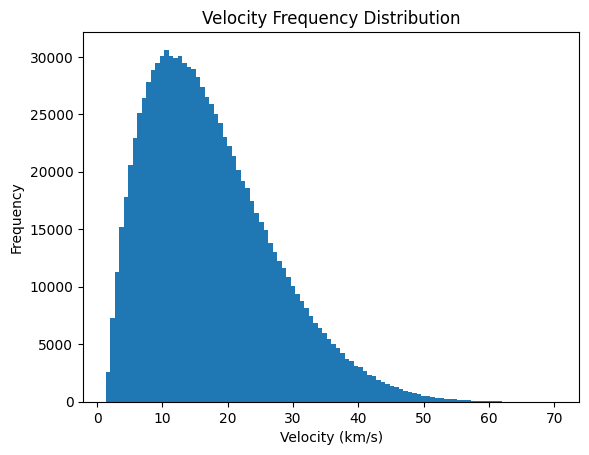

In [11]:
from scipy.stats import beta

# Parameters for a left-skewed beta distribution
a, b = 2, 8
samples = beta.rvs(a, b, size=len(neo_data))

# Compute statistics
mean_val = np.mean(samples)
median_val = np.median(samples)
rms_val = np.sqrt(np.mean(samples**2))
print(mean_val, median_val, rms_val)

# Normalize to match target mean and RMS
target_mean = 17.4
target_rms = 18.8

# Scale to match RMS
scaled_samples = samples * target_rms / rms_val

# Shift to match mean
scaled_samples += target_mean - np.mean(scaled_samples)
velocities = scaled_samples
plt.hist(velocities, bins=100)
plt.xlabel('Velocity (km/s)')
plt.ylabel('Frequency')
plt.title('Velocity Frequency Distribution')
plt.show()

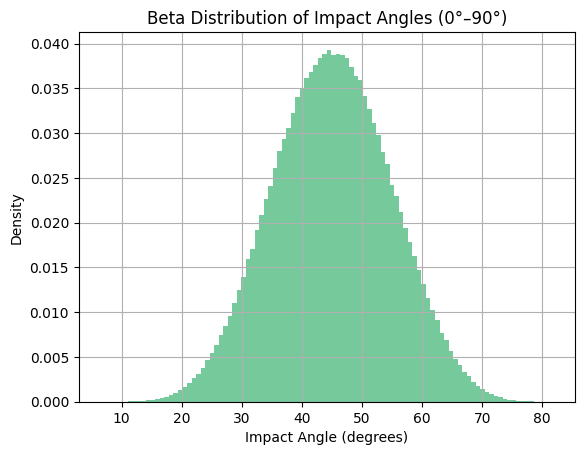

In [12]:
from scipy.stats import beta

a, b = 10, 10
samples = beta.rvs(a, b, size=len(neo_data))
angles = samples * 90

# Plot histogram
plt.hist(angles, bins=100, density=True, alpha=0.7, color='mediumseagreen')
plt.title('Beta Distribution of Impact Angles (0°–90°)')
plt.xlabel('Impact Angle (degrees)')
plt.ylabel('Density')
plt.grid(True)
plt.show()

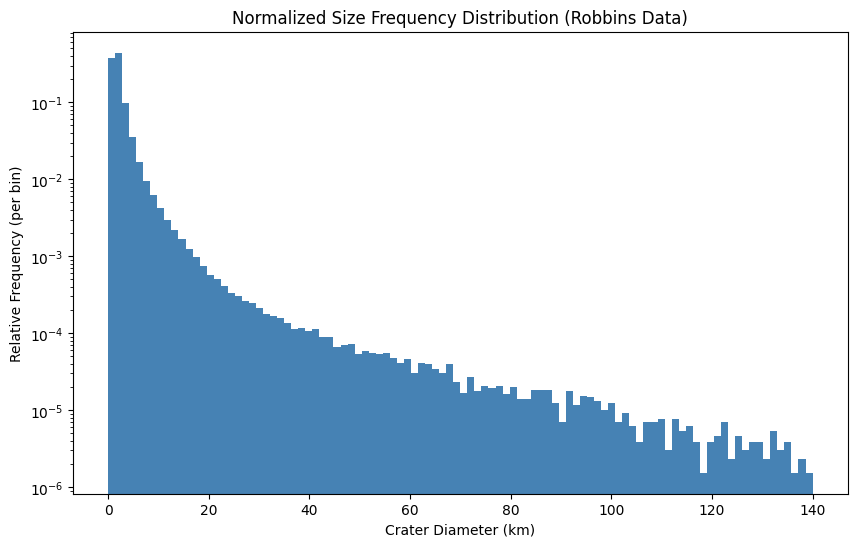

In [14]:
diameters1 = robbins_data['DIAM_CIRC_IMG'][robbins_data['DIAM_CIRC_IMG'] <= 140]
num_bins = 100
bin_edges = np.linspace(0, 140, num_bins + 1)
counts1, _ = np.histogram(diameters1, bins=bin_edges)
rel_freq1 = counts1 / len(diameters1)   # relative frequency per bin
bin_centers1 = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot Robbins data
plt.figure(figsize=(10, 6))
plt.bar(bin_centers1, rel_freq1, width=bin_edges[1]-bin_edges[0], color='steelblue')
plt.xlabel('Crater Diameter (km)')
plt.ylabel('Relative Frequency (per bin)')
plt.title('Normalized Size Frequency Distribution (Robbins Data)')
plt.yscale('log')
plt.show()

/tmp/ipython-input-758202057.py:20: RuntimeWarning: invalid value encountered in scalar power
  D_t = 1.16 * ((delta / rho) ** (1/3)) * (D_p ** 0.78) * ((v * math.sin(angle)) ** 0.43) * (g ** -0.22)


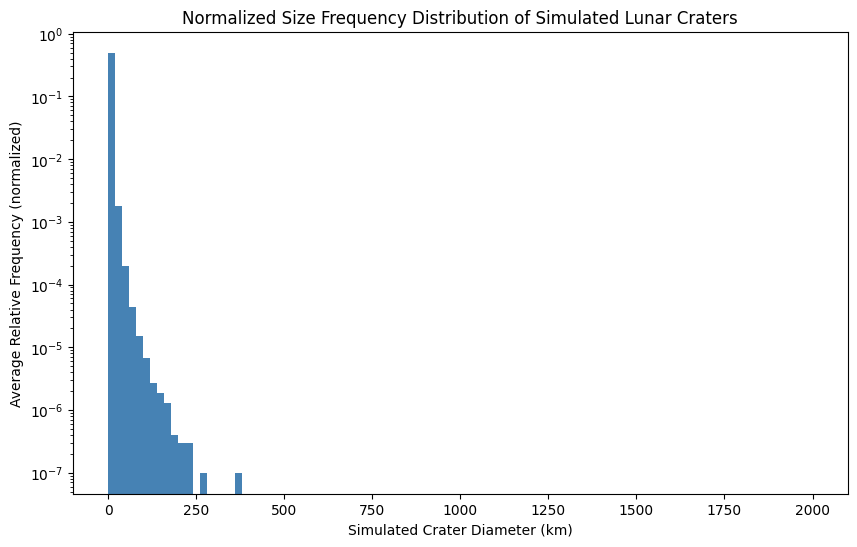

In [17]:
# Constants
delta = 3.34  # g/cm³
g = 0.00162   # km/s²
rho = 2.87

num_runs = 10
num_bins = 100
num_samples = len(neo_data)

bin_edges = np.linspace(0, 2000, num_bins + 1)
all_counts = []
D_p_vals = neo_data.iloc[:, 4].values

for _ in range(num_runs):
    D_vals = []
    for i in range(num_samples):
        D_p = D_p_vals[i]
        angle = random.choice(angles)
        v = random.choice(velocities)
        D_t = 1.16 * ((delta / rho) ** (1/3)) * (D_p ** 0.78) * ((v * math.sin(angle)) ** 0.43) * (g ** -0.22)
        D_vals.append(D_t)

    # Compute histogram for this run
    counts, _ = np.histogram(D_vals, bins=bin_edges)

    # Normalize counts by number of samples (relative frequency)
    counts = counts / num_samples
    all_counts.append(counts)

# Compute average relative frequency per bin
average_counts = np.mean(all_counts, axis=0)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot averaged normalized histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, average_counts, width=bin_edges[1] - bin_edges[0], color='steelblue')
plt.xlabel('Simulated Crater Diameter (km)')
plt.ylabel('Average Relative Frequency (normalized)')
plt.title('Normalized Size Frequency Distribution of Simulated Lunar Craters')
plt.yscale('log')
plt.show()

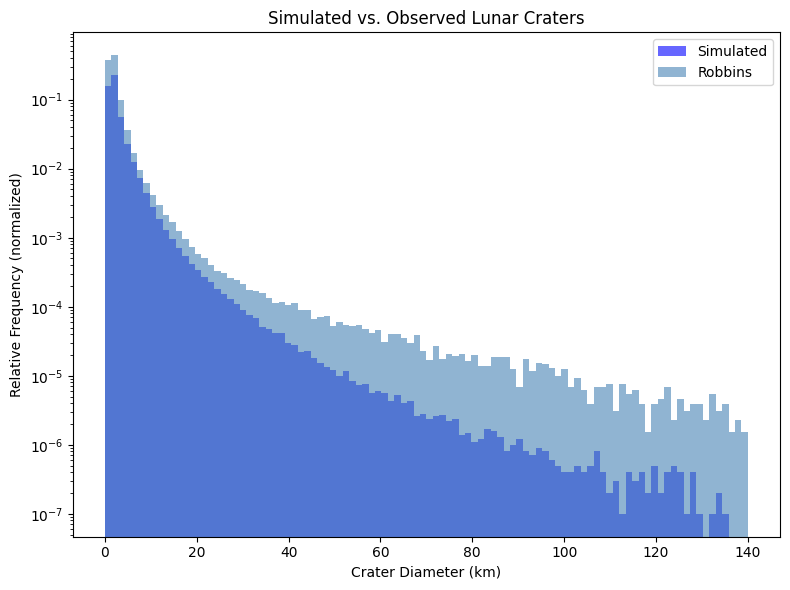

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# --- Overlay both crater distributions on the same axis ---
ax.bar(bin_centers, average_counts,
       width=bin_edges[1] - bin_edges[0],
       color='blue', alpha=0.6, label='Simulated')

ax.bar(bin_centers1, rel_freq1,
       width=bin_edges[1] - bin_edges[0],
       color='steelblue', alpha=0.6, label='Robbins')

# --- Axis labels and formatting ---
ax.set_xlabel('Crater Diameter (km)')
ax.set_ylabel('Relative Frequency (normalized)')
ax.set_title('Simulated vs. Observed Lunar Craters')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
print(len(diameters1), len(np.concatenate(D_t_final)))
from scipy.stats import ks_2samp
stat, p_value = ks_2samp(diameters1, np.concatenate(D_t_final))
alpha = 0.05
print(p_value)
if p_value < alpha:
    print("Reject the null hypothesis: distributions differ significantly.")
else:
    print("Fail to reject the null hypothesis: no significant difference detected.")

NameError: name 'D_t_final' is not defined

In [ ]:
print(sum(average_counts))
print(sum(rel_freq1))

0.5009735189824003
0.9999999999999993


In [ ]:
print(len(rel_freq1), len(average_counts))

from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(rel_freq1, average_counts)

print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)

# Interpret results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: distributions differ significantly.")
else:
    print("Fail to reject the null hypothesis: no significant difference detected.")

100 100
Mann-Whitney U statistic: 7029.0
p-value: 7.172501694147873e-07
Reject the null hypothesis: distributions differ significantly.


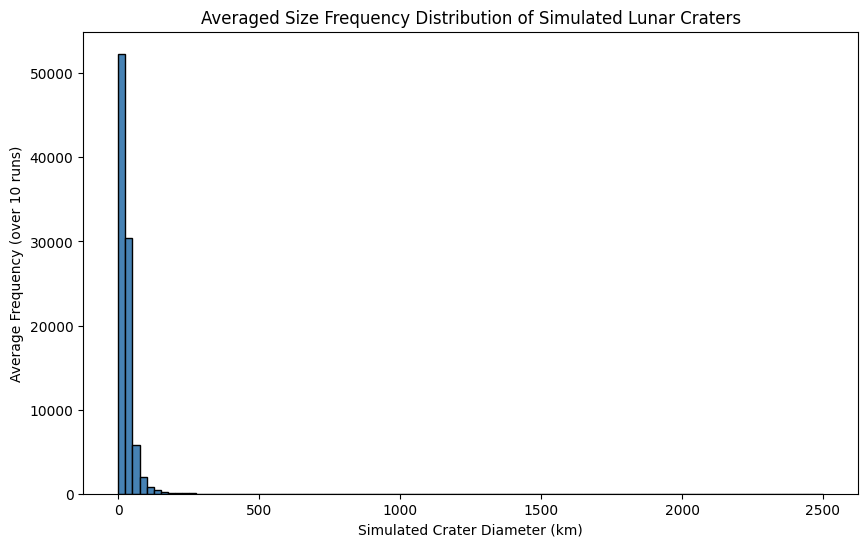

In [ ]:
#OLD CODE
num_runs = 10
num_bins = 100
num_samples = len(neo_data)

bin_edges = np.linspace(0, 2500, num_bins + 1)
all_counts = []

for _ in range(num_runs):
    velocities = [random.weibullvariate(1, 1.5) / 5 * 19 + 1 for _ in range(num_samples)]
    time = [(random.weibullvariate(1, 1.5) / 5) * 450000 for _ in range(num_samples)]

    sim = []
    for i in range(num_samples):
        velocity = random.choice(velocities)
        time_val = random.choice(time)
        diameter = random.choice(neo_data.iloc[:, 4])
        radius = diameter / 2
        crater_diameter = (2 * (velocity * time_val / radius) ** 0.36) * radius
        sim.append(crater_diameter)

    # Compute histogram for this run
    counts, _ = np.histogram(sim, bins=bin_edges)
    all_counts.append(counts)

# Compute average frequency per bin
average_counts = np.mean(all_counts, axis=0)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot averaged histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, average_counts, width=bin_edges[1] - bin_edges[0], color='steelblue', edgecolor='black')
plt.xlabel('Simulated Crater Diameter (km)')
plt.ylabel('Average Frequency (over 10 runs)')
plt.title('Averaged Size Frequency Distribution of Simulated Lunar Craters')
plt.show()

/tmp/ipython-input-1766432476.py:20: RuntimeWarning: invalid value encountered in scalar power
  D_t = 1.16 * ((delta/rho)**(1/3)) * (D_p**0.78) * ((v * math.sin(angle))**0.43) * (g**-0.22)


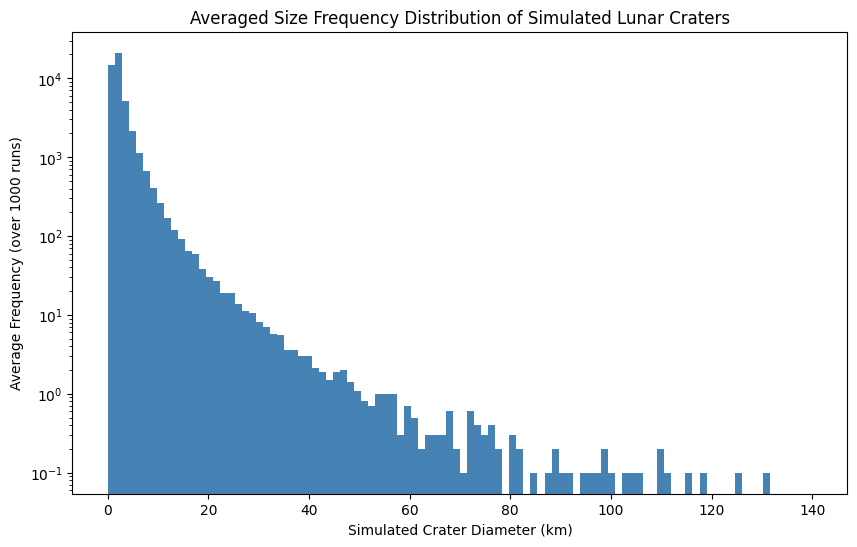

In [ ]:
delta = 3.34 # g/cm³
g = 0.00162 # km/s²
rho = 2.87

num_runs = 10
num_bins = 100
num_samples = len(neo_data)

bin_edges = np.linspace(0, 140, num_bins + 1)
all_counts = []
D_p_vals = neo_data.iloc[:, 4].values
D_t_final = []

for _ in range(num_runs):
    D_vals = []
    for i in range(num_samples):
        D_p = D_p_vals[i]
        angle = random.choice(angles)
        v = random.choice(velocities)
        D_t = 1.16 * ((delta/rho)**(1/3)) * (D_p**0.78) * ((v * math.sin(angle))**0.43) * (g**-0.22)
        D_vals.append(D_t)
    # Compute histogram for this run
    counts, _ = np.histogram(D_vals, bins=bin_edges)
    all_counts.append(counts)
    D_t_final.append(D_vals)

# Compute average frequency per bin
average_counts = np.mean(all_counts, axis=0)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot averaged histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, average_counts, width=bin_edges[1] - bin_edges[0], color='steelblue')
plt.xlabel('Simulated Crater Diameter (km)')
plt.ylabel('Average Frequency (over 1000 runs)')
plt.title('Averaged Size Frequency Distribution of Simulated Lunar Craters')
plt.yscale('log')
plt.show()

/tmp/ipython-input-3192465353.py:19: RuntimeWarning: invalid value encountered in scalar power
  D_t = 1.16 * ((delta/rho)**(1/3)) * (D_p**0.78) * ((v * math.sin(angle))**0.43) * (g**-0.22)


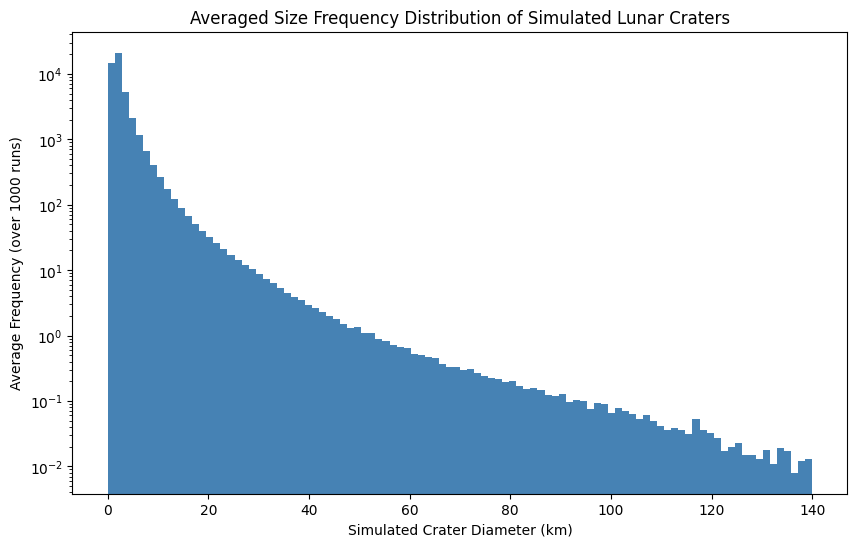

In [ ]:
delta = 3.34 # g/cm³
g = 0.00162 # km/s²
rho = 2.87

num_runs = 1000
num_bins = 100
num_samples = len(neo_data)

bin_edges = np.linspace(0, 140, num_bins + 1)
all_counts = []
D_p_vals = neo_data.iloc[:, 4].values

for _ in range(num_runs):
    D_vals = []
    for i in range(num_samples):
        D_p = D_p_vals[i]
        angle = random.choice(angles)
        v = random.choice(velocities)
        D_t = 1.16 * ((delta/rho)**(1/3)) * (D_p**0.78) * ((v * math.sin(angle))**0.43) * (g**-0.22)
        D_vals.append(D_t)
    # Compute histogram for this run
    counts, _ = np.histogram(D_vals, bins=bin_edges)
    all_counts.append(counts)

# Compute average frequency per bin
average_counts = np.mean(all_counts, axis=0)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot averaged histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, average_counts, width=bin_edges[1] - bin_edges[0], color='steelblue')
plt.xlabel('Simulated Crater Diameter (km)')
plt.ylabel('Average Frequency (over 1000 runs)')
plt.title('Averaged Size Frequency Distribution of Simulated Lunar Craters')
plt.yscale('log')
plt.show()

/tmp/ipython-input-2951979090.py:11: RuntimeWarning: invalid value encountered in scalar power
  D_t = 1.16 * ((delta/rho)**(1/3)) * (D_p**0.78) * ((v * math.sin(angle))**0.43) * (g**-0.22)


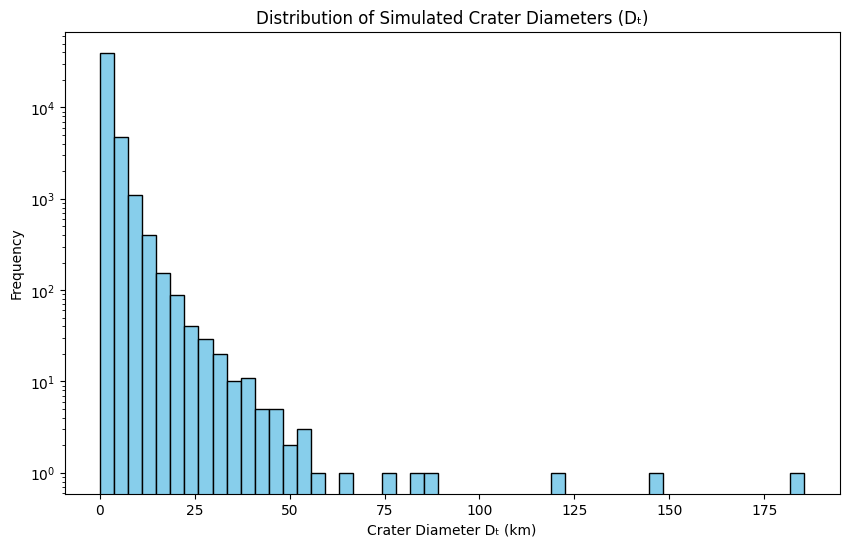

In [ ]:
# Scaling law
delta = 3.34 # g/cm³
g = 0.00162 # km/s²
rho = 2.87
D_vals = []

for i in range(len(neo_data)):
  D_p = neo_data.iloc[i, 4]
  angle = angles[i]
  v = random.choice(velocities)
  D_t = 1.16 * ((delta/rho)**(1/3)) * (D_p**0.78) * ((v * math.sin(angle))**0.43) * (g**-0.22)
  D_vals.append(D_t)

plt.figure(figsize=(10, 6))
plt.hist(D_vals, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Simulated Crater Diameters (Dₜ)")
plt.xlabel("Crater Diameter Dₜ (km)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.show()